# Exercise_4.09_Tasks - Part 2.1

1 - Create a new notebook, import the necessary analysis and visualization libraries, then import your most up-to-date project data (i.e., the data set with your new customer data from the first part of this task).

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [7]:
# create path
path='/home/haus/Exercise_4_Instacart_Basket_Analysis'

In [9]:
# Importing data-frame Customers
df_cop=pd.read_pickle(r'/home/haus/Exercise_4_Instacart_Basket_Analysis/02_Data/Prepared_Data/cust_ords_prods_merged.pkl')

2 - If you haven’t done so already, follow the instructions in the Exercise to create a bar chart, a histogram, a scatterplot, and a line chart, using a sample subset for the line chart.

<Axes: xlabel='order_dow'>

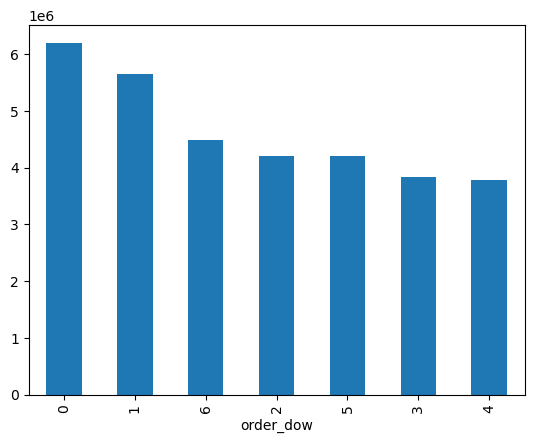

In [12]:
# Create a bar chart (order from largest to smallest)
df_cop['order_dow'].value_counts().plot.bar()

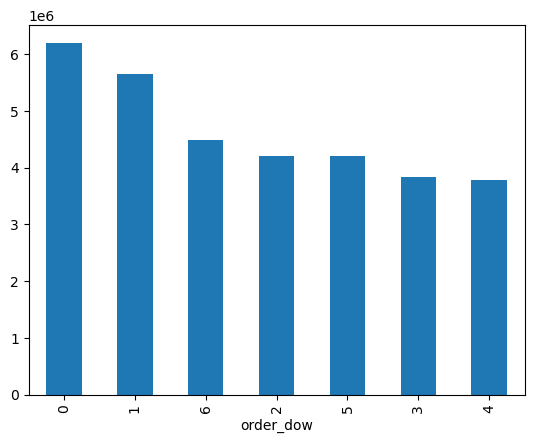

In [14]:
# Save the bar chart within the bar object (it can be accessed by using the function bar.figure)
bar=df_cop['order_dow'].value_counts().plot.bar()

In [16]:
# Export the bar chart as an image file to a specific folder using the function figure.savefig()
bar.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'bar_order_dow1.png'))

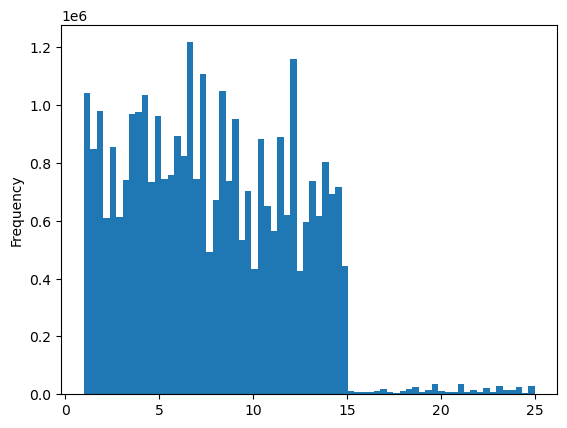

In [18]:
# Create a histogram chart for column “prices” (the argument within the parentheses it helps to determine the granularity of the histogram)
hist=df_cop['prices'].plot.hist(bins = 70)

In [20]:
# Export the histogram chart as an image file to a specific folder using the function figure.savefig():
hist.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'hist_prices_g70_1.png'))

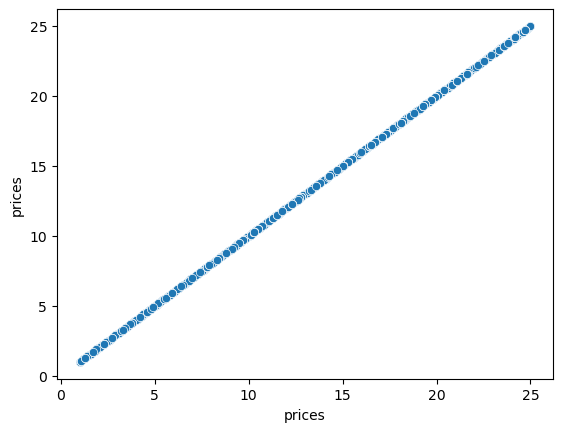

In [22]:
# Create a scatterplot chart for column “prices”
plt.figure()  # Start a new figure
sns.scatterplot(x = 'prices', y = 'prices', data=df_cop)
# Export the scatterplot chart as an image file to a specific folder using the function savefig():
plt.savefig('/home/haus/Exercise_4_Instacart_Basket_Analysis/04_Analysis/Visualizations/scatterplot.png', dpi=300)

In [23]:
# Grouping data by 'order_dow' and calculating the mean of 'prices'
prices_by_dow = df_cop.groupby('order_dow')['prices'].mean()

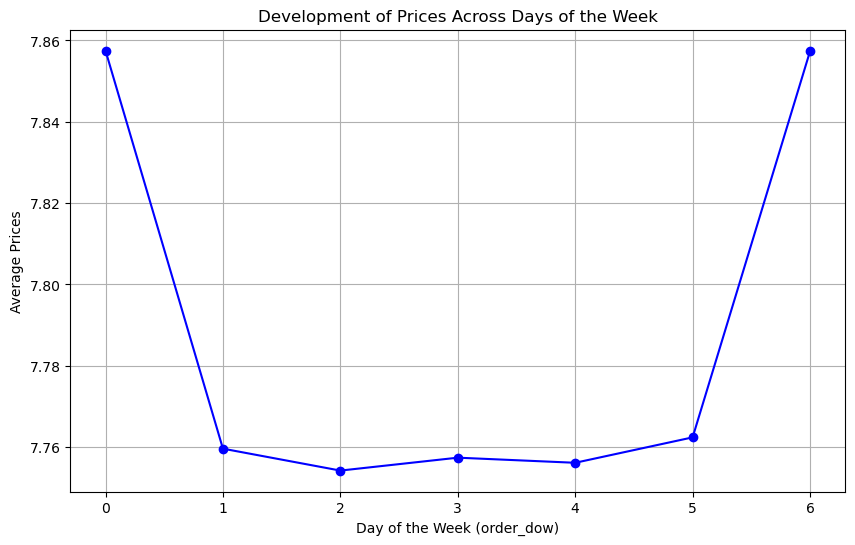

In [24]:
# Creating the line chart by creating a figure explicitly and store reference:
fig2 = plt.figure(figsize=(10, 6))
plt.plot(prices_by_dow.index, prices_by_dow.values, marker='o', linestyle='-', color='blue')
plt.title('Development of Prices Across Days of the Week')
plt.xlabel('Day of the Week (order_dow)')
plt.ylabel('Average Prices')
plt.grid(True)

In [28]:
# Save the line chart plot to a file before exporting to a folder
fig2.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'prices_across_dow.png'), dpi=300, bbox_inches='tight')

3 - You need to provide the Instacart senior stakeholders with descriptive findings about sales. Create a histogram of the “order_hour_of_day” column.
In a markdown cell beneath your histogram, describe what the histogram demonstrates.

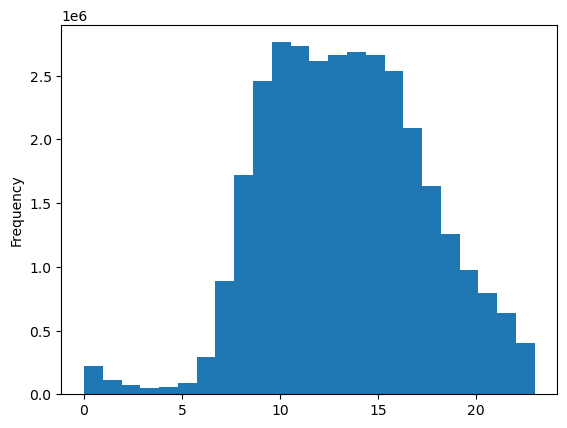

In [31]:
# Create a histogram chart for column “order_hour_of_day” (the argument within the parentheses it helps to determine the granularity of the histogram)
hist2=df_cop['order_hour_of_day'].plot.hist(bins = 24)

The histogram shows peaks during certain hours, which indicate the times of day when the most orders are placed. If this peak occurs during midday or early evening, it might suggest that customers prefer to shop during their lunch hours or after work. The shape of the distribution could tell us if the ordering pattern is concentrated within a specific part of the day or if it is relatively uniform. A normal distribution might suggest a consistent shopping pattern centered around a particular time, while a skewed distribution could indicate a tendency to shop during specific times, like afternoons or evenings.

In [34]:
# Export the histogram chart as an image file to a specific folder using the function figure.savefig():
hist2.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'order_hour_of_day.png'))

4 - The marketing team is curious about the distribution of orders among customers in terms of loyalty. Create a bar chart from the “loyalty_flag” column.

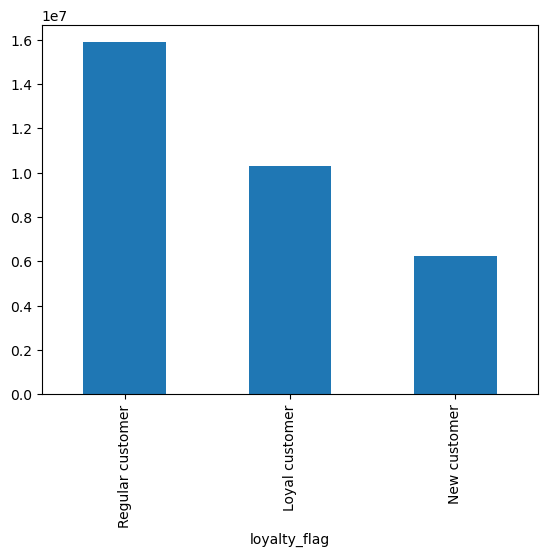

In [37]:
# Create a bar chart (order from largest to smallest)
bar2=df_cop['loyalty_flag'].value_counts().plot.bar()

In [39]:
# Save the bar chart within the bar object (it can be accessed by using the function bar.figure)
bar2.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'loyalty_flag.png'), bbox_inches='tight')

In [41]:
# Export the bar chart as an image file to a specific folder using the function figure.savefig()
bar2.figure.savefig(os.path.join(path, '04_Analysis', 'Visualizations', 'loyalty_flag.png'), bbox_inches='tight')

5 - Check whether there’s a difference in expenditure (the “prices” column) depending on the hour of the day. (Hint: To check this, you need to use an accurate sample for your line chart!)

In [44]:
# Retrieve data-frame column name
df_cop.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'first_order',
       'product_id', 'add_to_cart_order', 'reordered', 'Unnamed: 0_y',
       'product_name', 'aisle_id', 'department_id', 'prices', 'merge_info',
       'price_range_loc', 'busiest_day', 'Busiest_days',
       'busiest_period_of_day', 'max_order', 'loyalty_flag', 'average_spend',
       'spending_flag', 'Customer_frequency', 'frequency_flag', 'first_name',
       'last_name', 'gender', 'state', 'age', 'date_joined', 'n_dependants',
       'marital_status', 'income'],
      dtype='object')

Option 1: Using the Full DataFrame (df_cop)

In [47]:
# Group by hour and calculate mean expenditure
hourly_expenditure = df_cop.groupby('order_hour_of_day')['prices'].mean()

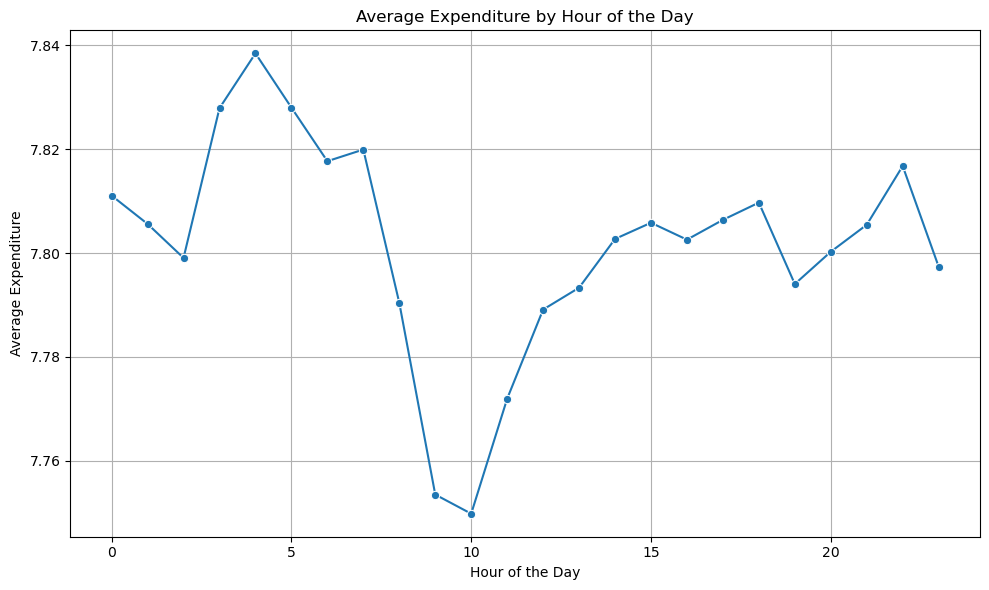

In [49]:
# Create the line chart
fig3 = plt.figure(figsize=(10, 6))
sns.lineplot(x=hourly_expenditure.index, y=hourly_expenditure.values, marker='o')
plt.title('Average Expenditure by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Expenditure')
plt.grid(True)
plt.tight_layout()

In [51]:
# Export the chart
fig3.savefig('/home/haus/Exercise_4_Instacart_Basket_Analysis/04_Analysis/Visualizations/avg_expenditure_by_hour_full.png', bbox_inches='tight')

Option 2: Using a Representative Sample of the full data-frame (df_cop)

In [54]:
# 80/20 split: use 80% of the data as a sample
df_sample = df_cop.sample(frac=0.8, random_state=42)

In [56]:
# Group by hour and calculate mean expenditure for the sample
hourly_expenditure_sample = df_sample.groupby('order_hour_of_day')['prices'].mean()

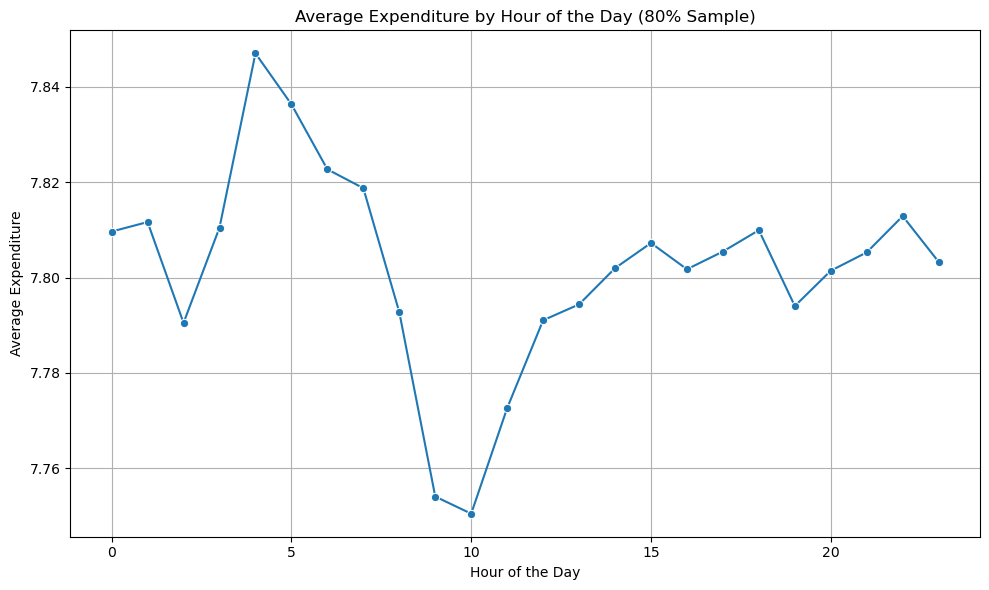

In [58]:
# Create and save the line chart
fig4=plt.figure(figsize=(10, 6))
sns.lineplot(x=hourly_expenditure_sample.index, y=hourly_expenditure_sample.values, marker='o')
plt.title('Average Expenditure by Hour of the Day (80% Sample)')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Expenditure')
plt.grid(True)
plt.tight_layout()

In [60]:
# Export the chart 
fig4.savefig('/home/haus/Exercise_4_Instacart_Basket_Analysis/04_Analysis/Visualizations/avg_expenditure_by_hour_sample.png', bbox_inches='tight')

## Close Part 2.1